# ECG Heartbeat Classification Project
## Phase 1 — Data Loading and Exploration

This notebook loads ECG signal data from the MIT-BIH Arrhythmia Database
using the WFDB library and explores the structure of the recordings.

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


### Load a single record from dataset

In [2]:
data_path = '../data/mit-bih-arrhythmia-database-1.0.0'

record = wfdb.rdrecord(os.path.join(data_path, '100'))

print("Record name:", record.record_name)
print("Number of signals:", record.n_sig)
print("Signal names:", record.sig_name)
print("Sampling frequency:", record.fs, "Hz")
print("Signal length:", record.sig_len, "samples")
print("Duration (seconds):", round(record.sig_len / record.fs, 1))

Record name: 100
Number of signals: 2
Signal names: ['MLII', 'V5']
Sampling frequency: 360 Hz
Signal length: 650000 samples
Duration (seconds): 1805.6


### Load Annotations

In [3]:
data_path = '../data/mit-bih-arrhythmia-database-1.0.0'

annotation = wfdb.rdann(os.path.join(data_path, '100'), 'atr')

print("Type of annotation object:", type(annotation))
print("Total heartbeats annotated:", len(annotation.sample))
print("First 20 symbols:", annotation.symbol[:20])


Type of annotation object: <class 'wfdb.io.annotation.Annotation'>
Total heartbeats annotated: 2274
First 20 symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


### Visualise the raw ECG signal
Plotting the first 10 seconds of the ECG to see the raw waveform.

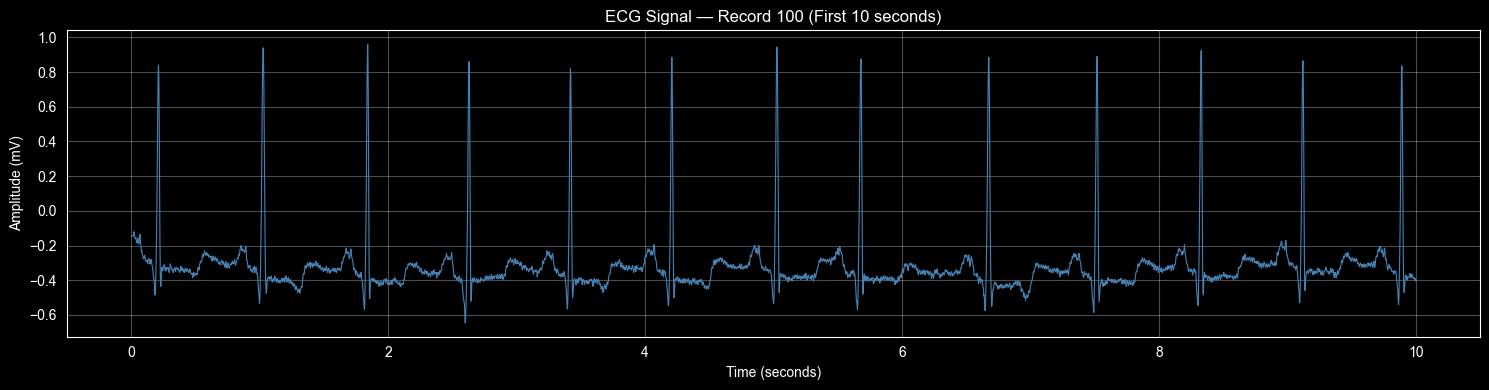

In [4]:
fs = record.fs  # 360 Hz
duration_sec = 10
samples = duration_sec * fs

# Extract signal (channel 0 = MLII lead)
signal = record.p_signal[:samples, 0]
time = np.arange(samples) / fs

plt.figure(figsize=(15, 4))
plt.plot(time, signal, color='steelblue', linewidth=0.8)
plt.title('ECG Signal — Record 100 (First 10 seconds)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

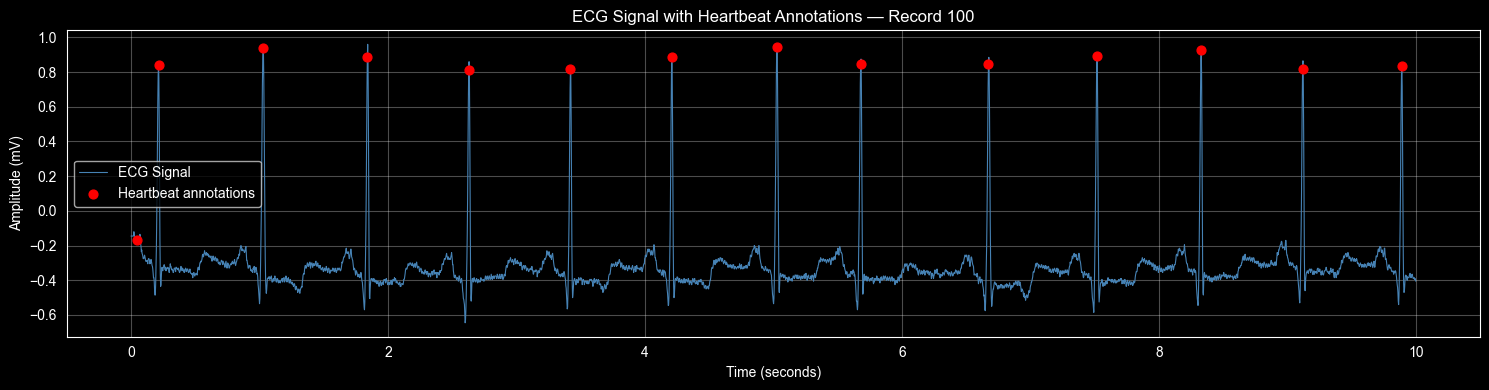

In [5]:
ann_samples = annotation.sample
ann_symbols = annotation.symbol

mask = ann_samples < samples
ann_in_window = ann_samples[mask]
sym_in_window = [ann_symbols[i] for i, m in enumerate(mask) if m]

plt.figure(figsize=(15, 4))
plt.plot(time, signal, color='steelblue', linewidth=0.8, label='ECG Signal')
plt.scatter(ann_in_window / fs, signal[ann_in_window],
            color='red', zorder=5, s=40, label='Heartbeat annotations')
plt.title('ECG Signal with Heartbeat Annotations — Record 100')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
from collections import Counter

beat_counts = Counter(annotation.symbol)
print("Beat type distribution for record 100:")
for symbol, count in sorted(beat_counts.items(), key=lambda x: -x[1]):
    print(f"  {symbol}: {count} beats")
    

Beat type distribution for record 100:
  N: 2239 beats
  A: 33 beats
  +: 1 beats
  V: 1 beats


### Description:
— the data is heavily imbalanced. 98% Normal, 2% abnormal just for the record 100(one patient). This is a class imbalance problem and need to handle it  in Phase 4 when training the model. If we don't, the model will just learn to say "everything is Normal" and still get 98% accuracy — which is useless medically. 



### Loading all 48 records
Looping through all records in the MIT-BIH database to get a complete 
picture of the dataset — total beats, beat type distribution across all patients.

In [6]:
# Get all record names from the database
records_path = '../data/mit-bih-arrhythmia-database-1.0.0'

all_records = []
for f in os.listdir(records_path):
    if f.endswith('.hea'):
        all_records.append(f.replace('.hea', ''))

all_records = sorted(all_records)
print(f"Total records found: {len(all_records)}")
print("Record names:", all_records)

Total records found: 48
Record names: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [7]:
from collections import Counter

all_beat_counts = Counter()
record_summary = []

for rec_name in all_records:
    try:
        ann = wfdb.rdann(os.path.join(records_path, rec_name), 'atr')
        counts = Counter(ann.symbol)
        all_beat_counts += counts
        record_summary.append({
            'record': rec_name,
            'total_beats': len(ann.sample),
            'N': counts.get('N', 0),
            'A': counts.get('A', 0),
            'V': counts.get('V', 0),
            'other': sum(v for k, v in counts.items() if k not in ['N', 'A', 'V'])
        })
    except Exception as e:
        print(f"Could not load record {rec_name}: {e}")

print("Done! Loaded all records.")

Done! Loaded all records.


In [8]:
summary_df = pd.DataFrame(record_summary)
print(summary_df.to_string(index=False))

record  total_beats    N    A   V  other
   100         2274 2239   33   1      1
   101         1874 1860    3   0     11
   102         2192   99    0   4   2089
   103         2091 2082    2   0      7
   104         2311  163    0   2   2146
   105         2691 2526    0  41    124
   106         2098 1507    0 520     71
   107         2140    0    0  59   2081
   108         1824 1739    4  17     64
   109         2535    0    0  38   2497
   111         2133    0    0   1   2132
   112         2550 2537    2   0     11
   113         1796 1789    0   0      7
   114         1890 1820   10  43     17
   115         1962 1953    0   0      9
   116         2421 2302    1 109      9
   117         1539 1534    1   0      4
   118         2301    0   96  16   2189
   119         2094 1543    0 444    107
   121         1876 1861    1   1     13
   122         2479 2476    0   0      3
   123         1519 1515    0   3      1
   124         1634    0    2  47   1585
   200         2

In [9]:
print("\nOverall beat distribution across entire database:")
print(f"Total beats: {sum(all_beat_counts.values())}")
print()
for symbol, count in sorted(all_beat_counts.items(), key=lambda x: -x[1]):
    percentage = count / sum(all_beat_counts.values()) * 100
    print(f"  {symbol}: {count} beats ({percentage:.1f}%)")


Overall beat distribution across entire database:
Total beats: 112647

  N: 75052 beats (66.6%)
  L: 8075 beats (7.2%)
  R: 7259 beats (6.4%)
  V: 7130 beats (6.3%)
  /: 7028 beats (6.2%)
  A: 2546 beats (2.3%)
  +: 1291 beats (1.1%)
  f: 982 beats (0.9%)
  F: 803 beats (0.7%)
  ~: 616 beats (0.5%)
  !: 472 beats (0.4%)
  ": 437 beats (0.4%)
  j: 229 beats (0.2%)
  x: 193 beats (0.2%)
  a: 150 beats (0.1%)
  |: 132 beats (0.1%)
  E: 106 beats (0.1%)
  J: 83 beats (0.1%)
  Q: 33 beats (0.0%)
  e: 16 beats (0.0%)
  [: 6 beats (0.0%)
  ]: 6 beats (0.0%)
  S: 2 beats (0.0%)



## Phase 1 Summary — Data Loading and Exploration

### What was achieved
Phase 1 successfully loaded and explored the MIT-BIH Arrhythmia Database
using the WFDB Python library. A complete understanding of the dataset
structure was established before moving into preprocessing and modelling.

### Dataset overview
- **Source:** MIT-BIH Arrhythmia Database (PhysioNet)
- **Total patients:** 48 recordings
- **Recording duration:** ~30 minutes per patient
- **Sampling frequency:** 360 Hz (360 samples per second)
- **Total samples per record:** ~650,000
- **Leads captured:** MLII and V5

### Key findings
- **Total heartbeats across all 48 records:** 112,647
- **Average beats per patient:** ~2,347
- **Normal beats (N):** 75,052 — 66.6% of all beats
- **Abnormal beats (L, R, V, A, F etc):** ~37,595 — 33.4% of all beats

### Beat type distribution
| Symbol | Type | Count | Percentage |
|--------|------|-------|------------|
| N | Normal beat | 75,052 | 66.6% |
| L | Left bundle branch block | 8,075 | 7.2% |
| R | Right bundle branch block | 7,259 | 6.4% |
| V | Premature ventricular contraction | 7,130 | 6.3% |
| / | Paced beat | 7,028 | 6.2% |
| A | Atrial premature beat | 2,546 | 2.3% |
| F | Fusion beat | 803 | 0.7% |
| Other | Rhythm markers / rare beats | 754 | 0.7% |

### Important observation — class imbalance
The dataset is heavily imbalanced with Normal beats making up 66.6% of
all data. This must be addressed during model training in Phase 4 to
prevent the model from simply predicting everything as Normal.

